# Exploratory Data Analysis (EDA)
## AI-Driven Coronary Disease Detection and Decision Support System
### Patient Recommendation System

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive



# **1. Data Overview**
This section provides an overview of the dataset including the shape, columns, missing values, and duplicate rows.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

# Load data
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DSGP/Heart_health new.csv")

# ===== 1. DATA OVERVIEW =====
print("="*50)
print("1. DATA OVERVIEW")
print("="*50)
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1. DATA OVERVIEW
Shape: (724, 12)

Columns: ['ID', 'Name', 'Age', 'Gender', 'Height cm', 'Weight kg', 'Blood Pressure mmHg', 'Cholesterol mg/dL', 'Glucose mg/dL', 'Smoker', 'Exercise hours/week', 'Heart Attack']

Missing values:
ID                     0
Name                   0
Age                    0
Gender                 0
Height cm              0
Weight kg              0
Blood Pressure mmHg    0
Cholesterol mg/dL      0
Glucose mg/dL          0
Smoker                 0
Exercise hours/week    0
Heart Attack           0
dtype: int64

Duplicate rows: 10



# **2. Target Variable Analysis**
In this step, we analyze the target variable `Heart Attack` by examining the distribution of cases (whether or not heart attack occurred).
We also look into the percentage distribution and analyze the data based on gender.



2. TARGET VARIABLE: HEART ATTACK


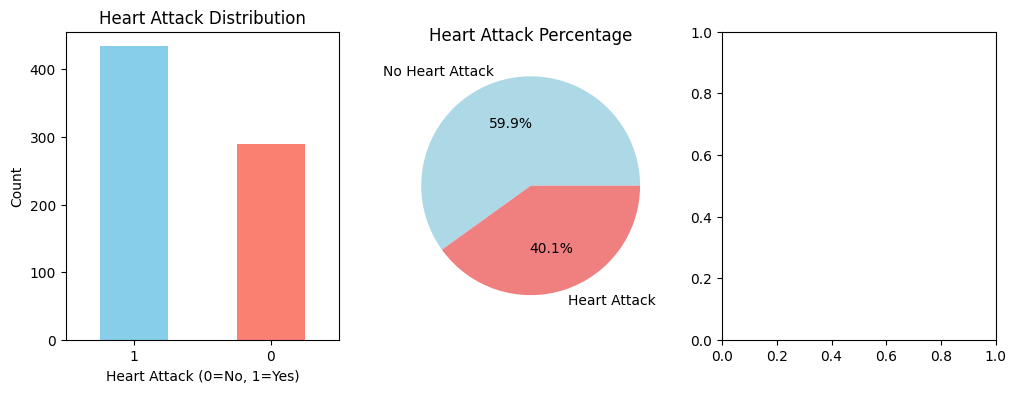

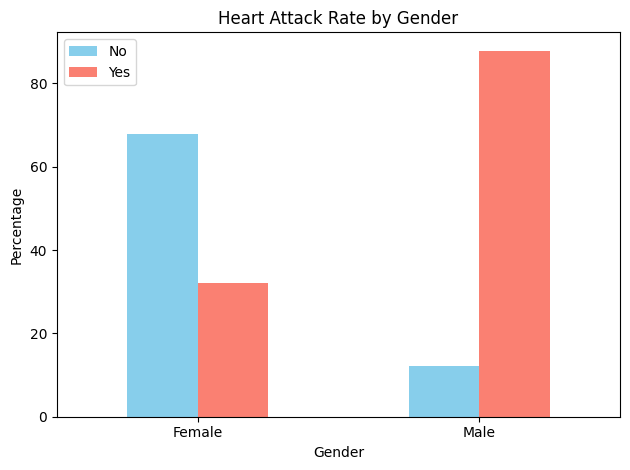

Heart Attack Rate: 59.9%

Heart Attack by Gender:
Heart Attack          0          1
Gender                            
Female        67.955801  32.044199
Male          12.154696  87.845304


In [ ]:

# ===== 2. TARGET VARIABLE ANALYSIS =====
print("\n" + "="*50)
print("2. TARGET VARIABLE: HEART ATTACK")
print("="*50)
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
df['Heart Attack'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Heart Attack Distribution')
plt.xlabel('Heart Attack (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 3, 2)
heart_attack_rate = df['Heart Attack'].value_counts(normalize=True) * 100
plt.pie(heart_attack_rate.values, labels=['No Heart Attack', 'Heart Attack'],
        autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Heart Attack Percentage')

plt.subplot(1, 3, 3)
# Heart attack by gender
gender_attack = pd.crosstab(df['Gender'], df['Heart Attack'], normalize='index') * 100
gender_attack.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Heart Attack Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.legend(['No', 'Yes'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(f"Heart Attack Rate: {heart_attack_rate[1]:.1f}%")
print(f"\nHeart Attack by Gender:")
print(gender_attack)



# **3. Critical Feature Engineering**
In this section, we focus on feature engineering. We will calculate new features like BMI, split Blood Pressure into systolic and diastolic, and categorize various features such as blood pressure and cholesterol.


In [ ]:

# ===== 3. CRITICAL FEATURE ENGINEERING =====
print("\n" + "="*50)
print("3. FEATURE ENGINEERING")
print("="*50)

# Split Blood Pressure
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure mmHg'].str.split('/', expand=True).astype(int)

# Calculate BMI
df['Height_m'] = df['Height cm'] / 100
df['BMI'] = df['Weight kg'] / (df['Height_m'] ** 2)

# Create categories
df['BP_Category'] = pd.cut(df['Systolic_BP'],
                          bins=[0, 120, 130, 140, 180],
                          labels=['Normal', 'Elevated', 'Stage1', 'Stage2'])

df['Cholesterol_Cat'] = pd.cut(df['Cholesterol mg/dL'],
                              bins=[0, 200, 240, 300],
                              labels=['Normal', 'Borderline', 'High'])

df['Age_Group'] = pd.cut(df['Age'],
                         bins=[20, 35, 50, 65, 80],
                         labels=['Young', 'Middle', 'Senior', 'Elderly'])

print("Created Features:")
print(f"- Systolic/Diastolic BP")
print(f"- BMI: {df['BMI'].mean():.1f} \u00B1 {df['BMI'].std():.1f}")
print(f"- BP Categories: {df['BP_Category'].value_counts().to_dict()}")
print(f"- Cholesterol Categories: {df['Cholesterol_Cat'].value_counts().to_dict()}")



3. FEATURE ENGINEERING
Created Features:
- Systolic/Diastolic BP
- BMI: 25.8 ± 0.5
- BP Categories: {'Elevated': 462, 'Normal': 244, 'Stage1': 18, 'Stage2': 0}
- Cholesterol Categories: {'Borderline': 434, 'Normal': 290, 'High': 0}



# **4. Risk Factor Analysis**
We analyze how different risk factors (such as smoking, blood pressure, cholesterol, and age) impact the likelihood of a heart attack. This is visualized through bar charts, with comparisons between categories of each risk factor.



4. RISK FACTOR ANALYSIS


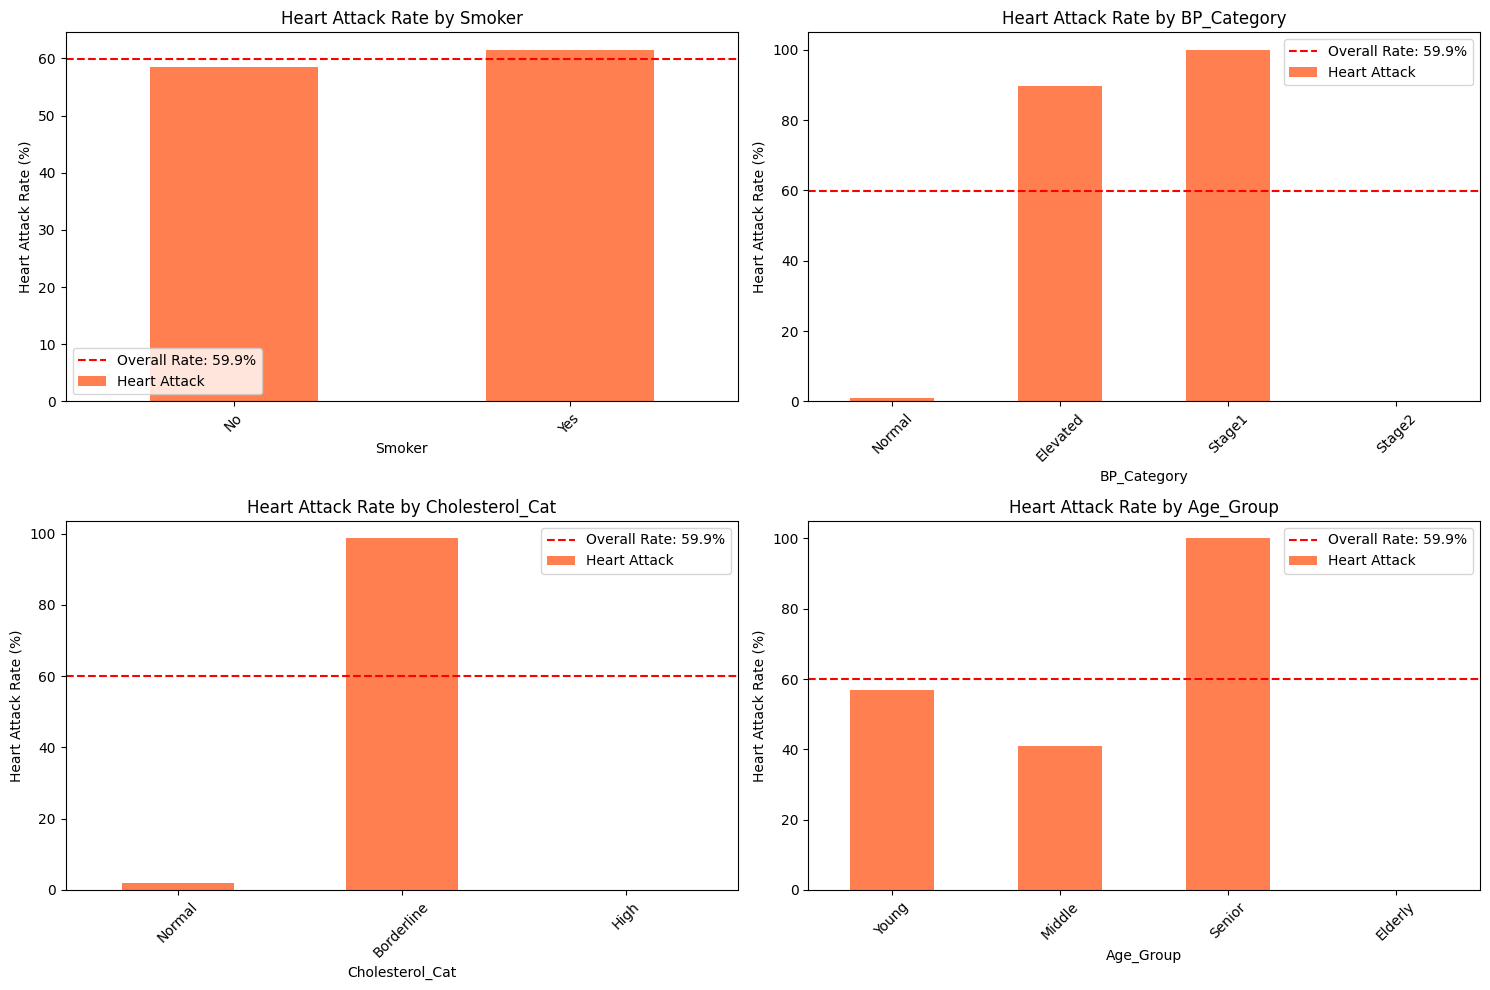

In [ ]:

# ===== 4. RISK FACTOR ANALYSIS =====
print("\n" + "="*50)
print("4. RISK FACTOR ANALYSIS")
print("="*50)

risk_factors = ['Smoker', 'BP_Category', 'Cholesterol_Cat', 'Age_Group']
plt.figure(figsize=(15, 10))

for i, factor in enumerate(risk_factors, 1):
    plt.subplot(2, 2, i)
    # Calculate heart attack rate for each category
    risk_data = df.groupby(factor)['Heart Attack'].mean() * 100
    risk_data.plot(kind='bar', color='coral')
    plt.title(f'Heart Attack Rate by {factor}')
    plt.ylabel('Heart Attack Rate (%)')
    plt.xticks(rotation=45)
    plt.axhline(y=df['Heart Attack'].mean()*100, color='red', linestyle='--',
                label=f'Overall Rate: {df["Heart Attack"].mean()*100:.1f}%')
    plt.legend()

plt.tight_layout()
plt.show()



# **5. Numerical Features Distribution**
This section visualizes the distribution of numerical features using histograms and KDE plots. This helps in understanding the spread and skewness of the data.



5. NUMERICAL FEATURES DISTRIBUTION


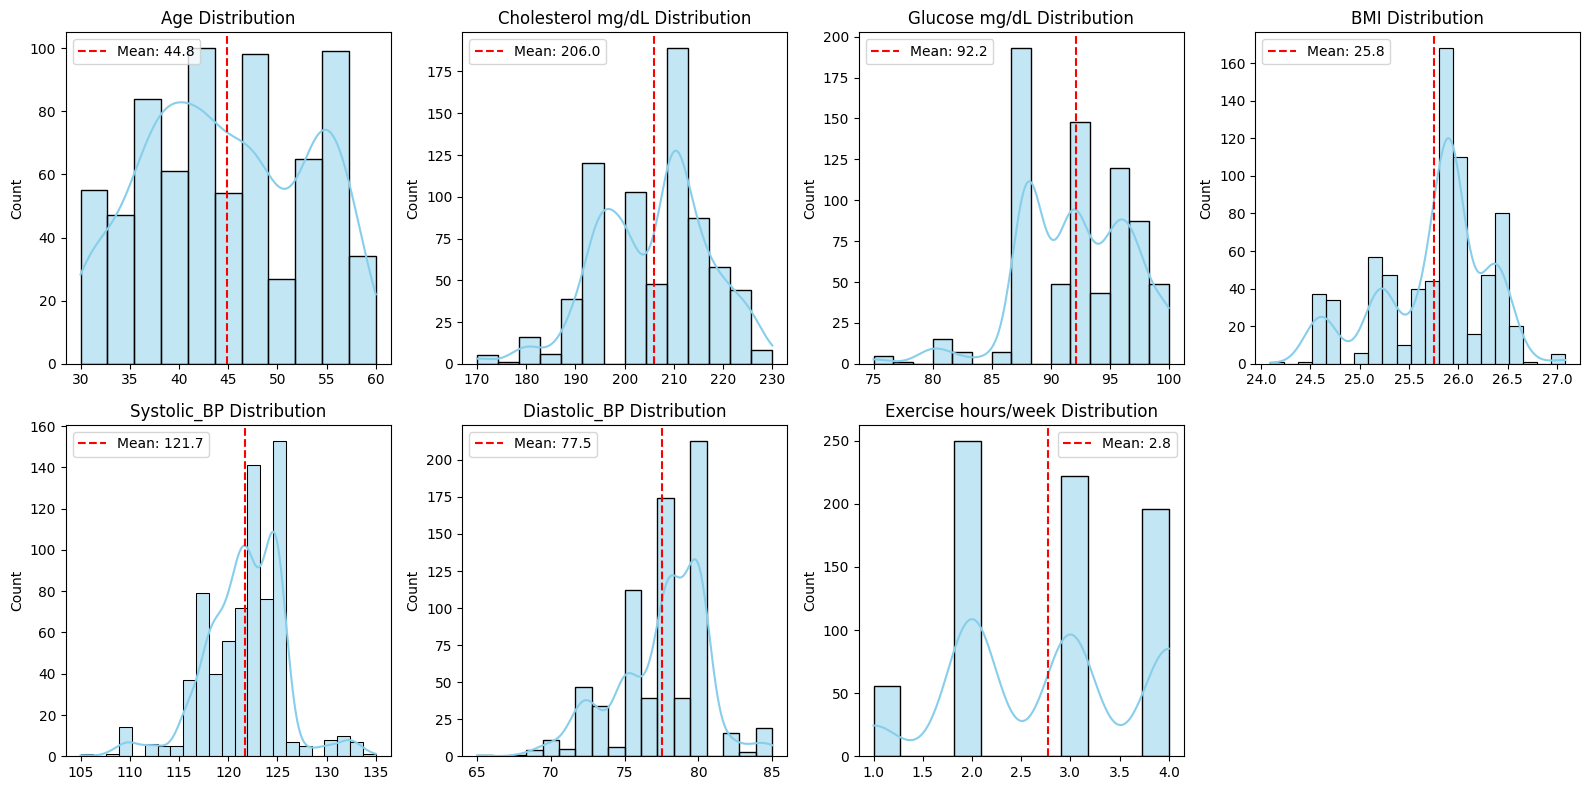

In [ ]:

# ===== 5. NUMERICAL FEATURES DISTRIBUTION =====
print("\n" + "="*50)
print("5. NUMERICAL FEATURES DISTRIBUTION")
print("="*50)

num_features = ['Age', 'Cholesterol mg/dL', 'Glucose mg/dL', 'BMI',
                'Systolic_BP', 'Diastolic_BP', 'Exercise hours/week']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, feature in enumerate(num_features):
    # Distribution with KDE
    sns.histplot(df[feature], kde=True, ax=axes[i], color='skyblue')
    axes[i].axvline(df[feature].mean(), color='red', linestyle='--', label=f'Mean: {df[feature].mean():.1f}')
    axes[i].set_title(f'{feature} Distribution')
    axes[i].set_xlabel('')
    axes[i].legend()

# Remove empty subplot
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



# **6. Correlation Analysis**
In this step, we analyze the correlation between numerical features. This helps to identify which features are most related to heart attack and can be used for prediction.



6. CORRELATION WITH HEART ATTACK


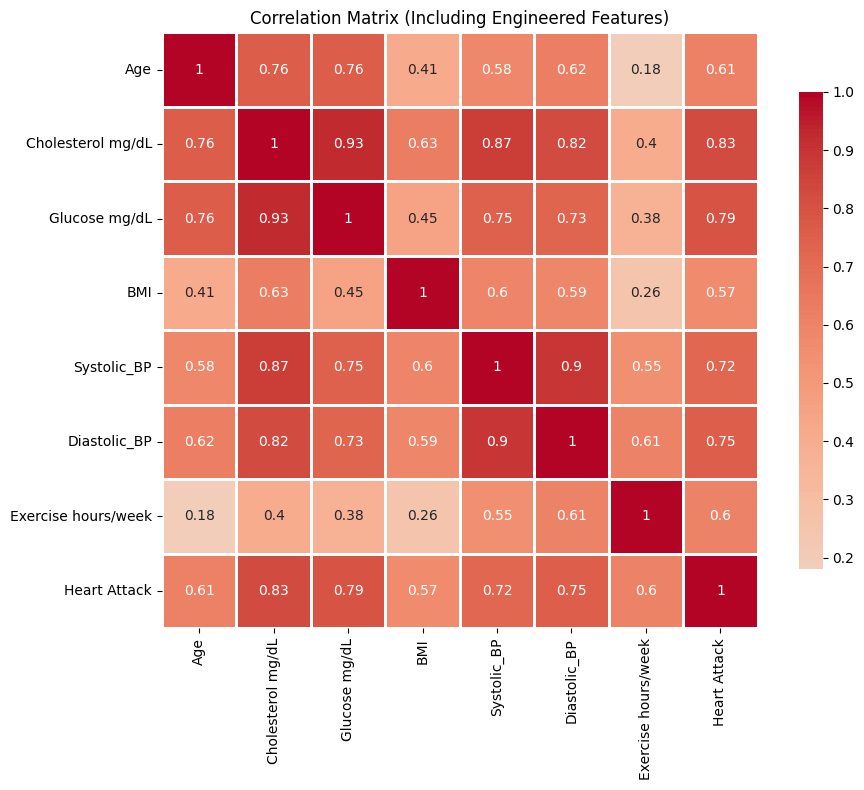


Top Correlations with Heart Attack:
Cholesterol mg/dL: 0.827
Glucose mg/dL: 0.793
Diastolic_BP: 0.755
Systolic_BP: 0.719
Age: 0.614
Exercise hours/week: 0.605
BMI: 0.571


In [ ]:

# ===== 6. CORRELATION WITH HEART ATTACK =====
print("\n" + "="*50)
print("6. CORRELATION WITH HEART ATTACK")
print("="*50)

# Select numeric columns including engineered features
numeric_cols = num_features + ['Heart Attack']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix (Including Engineered Features)')
plt.tight_layout()
plt.show()

print("\nTop Correlations with Heart Attack:")
heart_corr = correlation_matrix['Heart Attack'].sort_values(ascending=False)
for feature, corr in heart_corr.items():
    if feature != 'Heart Attack' and abs(corr) > 0.1:
        print(f"{feature}: {corr:.3f}")



# **7. Interaction Effects**
This section looks at the interaction between certain features, such as smoking and high cholesterol, as well as exercise habits, to assess their combined effect on heart attack risk.



7. INTERACTION EFFECTS


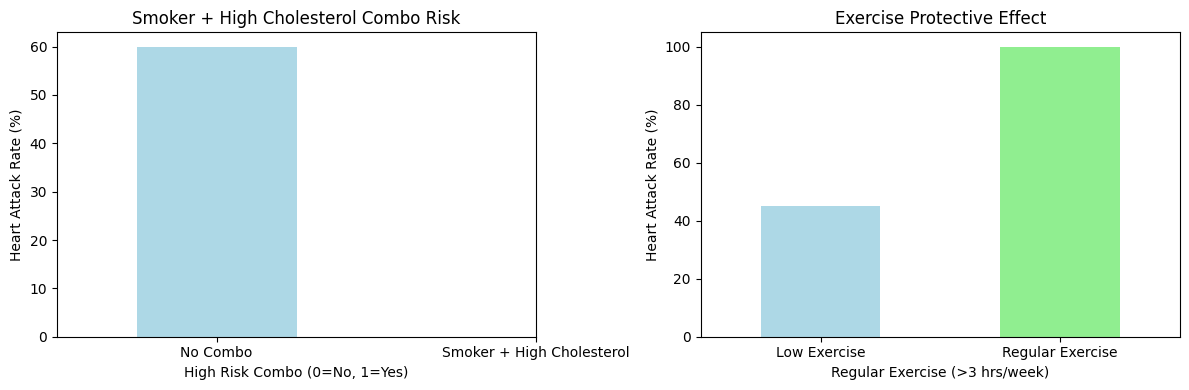

In [ ]:

# ===== 7. INTERACTION EFFECTS =====
print("\n" + "="*50)
print("7. INTERACTION EFFECTS")
print("="*50)

# Smoker + High Cholesterol interaction
df['HighRisk_Combo'] = ((df['Smoker'] == 'Yes') &
                        (df['Cholesterol_Cat'] == 'High')).astype(int)

# Exercise protection effect
df['Exercise_Protective'] = (df['Exercise hours/week'] > 3).astype(int)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
combo_risk = df.groupby('HighRisk_Combo')['Heart Attack'].mean() * 100
combo_risk.plot(kind='bar', color=['lightblue', 'coral'])
plt.title('Smoker + High Cholesterol Combo Risk')
plt.xlabel('High Risk Combo (0=No, 1=Yes)')
plt.ylabel('Heart Attack Rate (%)')
plt.xticks([0, 1], ['No Combo', 'Smoker + High Cholesterol'], rotation=0)

plt.subplot(1, 2, 2)
exercise_effect = df.groupby('Exercise_Protective')['Heart Attack'].mean() * 100
exercise_effect.plot(kind='bar', color=['lightblue', 'lightgreen'])
plt.title('Exercise Protective Effect')
plt.xlabel('Regular Exercise (>3 hrs/week)')
plt.ylabel('Heart Attack Rate (%)')
plt.xticks([0, 1], ['Low Exercise', 'Regular Exercise'], rotation=0)

plt.tight_layout()
plt.show()



# **8. Key Insights Summary**
This section summarizes the key insights derived from the analysis. It provides valuable information to inform the recommendation system.


In [ ]:

# ===== 8. KEY INSIGHTS SUMMARY =====
print("\n" + "="*50)
print("8. KEY INSIGHTS FOR RECOMMENDATION SYSTEM")
print("="*50)

# Check if HighRisk_Combo index 1 exists before trying to access it
combo_risk_1_value = combo_risk.get(1, None)
if combo_risk_1_value is not None:
    highest_risk_group_str = f"Smokers with High Cholesterol: {combo_risk_1_value:.1f}% attack rate"
else:
    highest_risk_group_str = "No individuals found with Smoker + High Cholesterol combo"

insights = {
    "Overall Heart Attack Rate": f"{df['Heart Attack'].mean()*100:.1f}%",
    "Most Predictive Features": list(heart_corr.index[1:4]),
    "Highest Risk Group": highest_risk_group_str,
    "Exercise Benefit": f"Regular exercisers have {exercise_effect[0]-exercise_effect[1]:.1f}% lower risk",
    "Average Age of Heart Attack Patients": f"{df[df['Heart Attack']==1]['Age'].mean():.1f} years",
    "Critical Thresholds": {
        "Cholesterol": ">240 mg/dL (High)",
        "Systolic BP": ">140 mmHg (Stage 2)",
        "Exercise": "<3 hrs/week (Low)"
    }
}

for key, value in insights.items():
    print(f"\n{key}:")
    if isinstance(value, dict):
        for subkey, subvalue in value.items():
            print(f"  - {subkey}: {subvalue}")
    else:
        print(f"  {value}")



8. KEY INSIGHTS FOR RECOMMENDATION SYSTEM

Overall Heart Attack Rate:
  59.9%

Most Predictive Features:
  ['Cholesterol mg/dL', 'Glucose mg/dL', 'Diastolic_BP']

Highest Risk Group:
  No individuals found with Smoker + High Cholesterol combo

Exercise Benefit:
  Regular exercisers have -54.9% lower risk

Average Age of Heart Attack Patients:
  48.9 years

Critical Thresholds:
  - Cholesterol: >240 mg/dL (High)
  - Systolic BP: >140 mmHg (Stage 2)
  - Exercise: <3 hrs/week (Low)



# **9. Data Preparation for Recommendation System**
In this final section, the data is prepared and saved for use in the recommendation system. It includes the selected features and saves the preprocessed data to a new CSV file.


In [ ]:

# ===== 9. DATA PREPARATION FOR RECOMMENDATION SYSTEM =====
print("\n" + "="*50)
print("9. DATA READY FOR RECOMMENDATION SYSTEM")
print("="*50)

# Features to use in ML model
ml_features = [
    # Demographic
    'Age', 'Gender', 'BMI',
    # Clinical
    'Systolic_BP', 'Diastolic_BP', 'Cholesterol mg/dL', 'Glucose mg/dL',
    # Lifestyle
    'Smoker', 'Exercise hours/week',
    # Engineered
    'BP_Category', 'Cholesterol_Cat', 'Age_Group', 'HighRisk_Combo', 'Exercise_Protective'
]

print(f"Total features for ML model: {len(ml_features)}")
print(f"Sample of engineered features:")
print(df[['HighRisk_Combo', 'Exercise_Protective', 'BP_Category']].head())

# Save prepared dataset
df.to_csv('Heart_health_preprocessed.csv', index=False)
print("\n Preprocessed data saved as 'Heart_health_preprocessed.csv'")



9. DATA READY FOR RECOMMENDATION SYSTEM
Total features for ML model: 14
Sample of engineered features:
   HighRisk_Combo  Exercise_Protective BP_Category
0               0                    0      Normal
1               0                    0      Normal
2               0                    0      Normal
3               0                    0      Normal
4               0                    0      Normal

 Preprocessed data saved as 'Heart_health_preprocessed.csv'
